In [3]:
import pandas as pd

apercu = pd.read_csv("data/eu_raw.csv", nrows=5, low_memory=False)
print(apercu.shape[1], "colonnes")
print()
print(apercu.columns.tolist())

37 colonnes

['ID', 'Country', 'VFN', 'Mp', 'Mh', 'Man', 'MMS', 'Tan', 'T', 'Va', 'Ve', 'Mk', 'Cn', 'Ct', 'Cr', 'r', 'm (kg)', 'Mt', 'Enedc (g/km)', 'Ewltp (g/km)', 'Ft', 'Fm', 'ec (cm3)', 'ep (KW)', 'z (Wh/km)', 'IT', 'Ernedc (g/km)', 'Erwltp (g/km)', 'De', 'Vf', 'Status', 'year', 'Date of registration', 'Fuel consumption', 'ech', 'RLFI', 'Electric range (km)']


In [4]:
import os
print(os.listdir("data"))

['eu_raw.csv', 'vehicles.csv']


In [6]:
import pandas as pd

cols = ["Country", "Mk", "Cn", "m (kg)", "ec (cm3)", "ep (KW)", "Ft", "Fm",
        "Ewltp (g/km)", "z (Wh/km)", "Electric range (km)",
        "Fuel consumption", "year"]

morceaux = []
for chunk in pd.read_csv("data/eu_raw.csv", usecols=cols, chunksize=500_000, low_memory=False):
    morceaux.append(chunk[chunk["Country"] == "FR"])

fr = pd.concat(morceaux, ignore_index=True)

fr = fr.rename(columns={
    "Country": "pays",
    "Mk": "marque",
    "Cn": "modele",
    "m (kg)": "masse",
    "ec (cm3)": "cylindree",
    "ep (KW)": "puissance",
    "Ft": "carburant",
    "Fm": "mode_carburation",
    "Ewltp (g/km)": "co2",
    "z (Wh/km)": "conso_electrique",
    "Electric range (km)": "autonomie_electrique",
    "Fuel consumption": "consommation",
    "year": "annee",
})

print(fr.shape)
print()
print(fr["annee"].value_counts().sort_index())

(1731737, 13)

annee
2025    1731737
Name: count, dtype: int64


In [7]:
print(fr["marque"].value_counts().head(20))
print()
print(fr["carburant"].value_counts())
print()
print("Valeurs manquantes :")
print(fr.isnull().sum())

marque
RENAULT          310641
PEUGEOT          240327
DACIA            148201
CITROEN          124199
TOYOTA           116931
VOLKSWAGEN       115190
BMW               61738
SKODA             53236
HYUNDAI           50305
AUDI              49792
MERCEDES-BENZ     46102
FORD              39420
KIA               37413
MG                35219
OPEL              34011
NISSAN            29363
MINI              26510
TESLA             25485
CUPRA             23108
SUZUKI            21470
Name: count, dtype: int64

carburant
petrol             1106312
electric            339849
petrol/electric     108172
diesel              105915
lpg                  57607
e85                  11731
diesel/electric       1824
hydrogen               311
ng                      16
Name: count, dtype: int64

Valeurs manquantes :
pays                          0
marque                        0
modele                        0
masse                         0
co2                           0
carburant                

In [8]:
import numpy as np

def categorie(c):
    if c == "electric":
        return "electrique"
    if "/" in str(c):
        return "hybride"
    if c in ("petrol", "diesel", "lpg", "e85"):
        return "thermique"
    return "autre"

fr["categorie"] = fr["carburant"].apply(categorie)
print(fr["categorie"].value_counts())
print()

# Une ligne par version commercialisée, pas par immatriculation
catalogue = (
    fr.groupby(["marque", "modele", "carburant", "categorie"], as_index=False)
      .agg(
          masse=("masse", "median"),
          cylindree=("cylindree", "median"),
          puissance=("puissance", "median"),
          co2=("co2", "median"),
          consommation=("consommation", "median"),
          conso_electrique=("conso_electrique", "median"),
          autonomie_electrique=("autonomie_electrique", "median"),
          immatriculations=("marque", "size"),
      )
)

print("Catalogue :", catalogue.shape)
print()
print(catalogue.sort_values("immatriculations", ascending=False).head(10)[
    ["marque", "modele", "carburant", "consommation", "immatriculations"]
])

categorie
thermique     1281565
electrique     339849
hybride        109996
autre             327
Name: count, dtype: int64

Catalogue : (1215, 12)

       marque                     modele carburant  consommation  \
926   PEUGEOT                        208    petrol           4.6   
996   RENAULT                       CLIO    petrol           5.2   
923   PEUGEOT                       2008    petrol           4.9   
345   CITROEN                         C3    petrol           5.6   
408     DACIA                    SANDERO    petrol           5.4   
1009  RENAULT  RENAULT 5 E-TECH ELECTRIC  electric           NaN   
997   RENAULT         CLIO E-TECH HYBRID    petrol           4.3   
1117   TOYOTA               TOYOTA YARIS    petrol           4.0   
1118   TOYOTA         TOYOTA YARIS CROSS    petrol           4.5   
403     DACIA                     DUSTER    petrol           5.0   

      immatriculations  
926              68966  
996              50326  
923              48753  
34

In [9]:
print(fr["mode_carburation"].value_counts())
print()
print(fr[fr["modele"].str.contains("E-TECH HYBRID", na=False)][
    ["marque", "modele", "carburant", "mode_carburation"]
].head())

mode_carburation
H    754626
M    469633
E    339849
P    109996
B     57607
F        26
Name: count, dtype: int64

     marque              modele carburant mode_carburation
18  RENAULT  CLIO E-TECH HYBRID    petrol                H
51  RENAULT  CLIO E-TECH HYBRID    petrol                H
66  RENAULT  CLIO E-TECH HYBRID    petrol                H
72  RENAULT  CLIO E-TECH HYBRID    petrol                H
90  RENAULT  CLIO E-TECH HYBRID    petrol                H


In [10]:
CATEGORIES = {
    "M": "thermique",
    "B": "thermique",
    "F": "thermique",
    "H": "hybride",
    "P": "hybride_rechargeable",
    "E": "electrique",
}

fr["categorie"] = fr["mode_carburation"].map(CATEGORIES).fillna("autre")
print(fr["categorie"].value_counts())
print()

catalogue = (
    fr.groupby(["marque", "modele", "carburant", "categorie"], as_index=False)
      .agg(
          masse=("masse", "median"),
          cylindree=("cylindree", "median"),
          puissance=("puissance", "median"),
          co2=("co2", "median"),
          consommation=("consommation", "median"),
          conso_electrique=("conso_electrique", "median"),
          autonomie_electrique=("autonomie_electrique", "median"),
          immatriculations=("marque", "size"),
      )
)

print("Catalogue :", catalogue.shape)
print()
print(catalogue.groupby("categorie").agg(
    versions=("modele", "size"),
    conso_mediane=("consommation", "median"),
))

categorie
hybride                 754626
thermique               527266
electrique              339849
hybride_rechargeable    109996
Name: count, dtype: int64

Catalogue : (1290, 12)

                      versions  conso_mediane
categorie                                    
electrique                 323            NaN
hybride                    327            5.8
hybride_rechargeable       235            1.3
thermique                  405            6.5


In [11]:
import os
os.makedirs("data", exist_ok=True)

catalogue.to_csv("data/catalogue_fr_2025.csv", index=False)
print("Catalogue sauvegardé :", catalogue.shape)
print(os.path.getsize("data/catalogue_fr_2025.csv") // 1024, "Ko")

Catalogue sauvegardé : (1290, 12)
97 Ko


In [12]:
catalogue = pd.read_csv("data/catalogue_fr_2025.csv")

In [13]:
import pandas as pd

catalogue = pd.read_csv("data/catalogue_fr_2025.csv")

# Thermiques et hybrides : ceux qui ont une consommation en litres
conso = catalogue[catalogue["categorie"].isin(["thermique", "hybride"])].copy()
conso = conso.dropna(subset=["consommation"])

print(conso.shape)
print()
print(conso[["masse", "cylindree", "puissance", "consommation"]].describe())

(727, 12)

             masse    cylindree   puissance  consommation
count   727.000000   727.000000  727.000000    727.000000
mean   1661.645805  2087.720770  171.747593      7.108322
std     360.288450  1020.900873  124.103726      2.704631
min     650.000000   998.000000   46.000000      3.700000
25%    1422.000000  1496.000000   96.000000      5.350000
50%    1605.000000  1968.000000  110.000000      6.100000
75%    1885.000000  1999.000000  210.000000      7.650000
max    2866.000000  6749.000000  614.000000     20.100000


In [14]:
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

num_cols = ["masse", "cylindree", "puissance"]
cat_cols = ["carburant", "categorie", "marque"]

X = conso[num_cols + cat_cols]
y = conso["consommation"]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

prep = ColumnTransformer(
    [
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler())
        ]), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
    ],
    sparse_threshold=0
)

modele = Pipeline([
    ("prep", prep),
    ("model", HistGradientBoostingRegressor(random_state=42))
])

modele.fit(X_tr, y_tr)
pred = modele.predict(X_te)

print("Baseline MAE :", round(mean_absolute_error(y_te, np.full(len(y_te), y_tr.mean())), 2))
print("MAE          :", round(mean_absolute_error(y_te, pred), 2))
print("R²           :", round(r2_score(y_te, pred), 3))

cv = cross_val_score(modele, X_tr, y_tr, cv=5, scoring="r2")
print("CV R²        :", cv.mean().round(3), "±", cv.std().round(3))

Baseline MAE : 2.0
MAE          : 0.39
R²           : 0.955
CV R²        : 0.934 ± 0.007


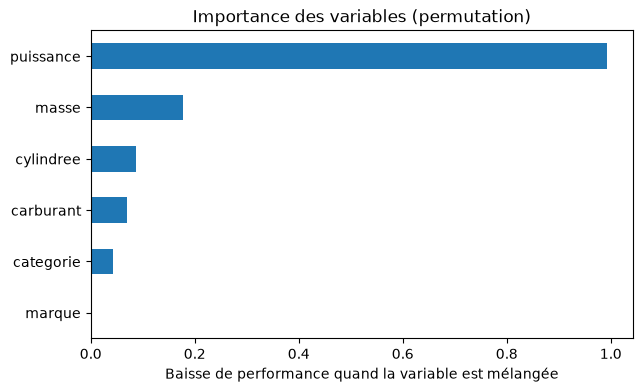

In [15]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

r = permutation_importance(modele, X_te, y_te, n_repeats=15, random_state=42)

noms = num_cols + cat_cols
imp = pd.Series(r.importances_mean, index=noms).sort_values()

imp.plot(kind="barh", figsize=(7, 4))
plt.title("Importance des variables (permutation)")
plt.xlabel("Baisse de performance quand la variable est mélangée")
plt.show()

In [16]:
print(conso[["masse", "cylindree", "puissance", "consommation"]].corr().round(2))

              masse  cylindree  puissance  consommation
masse          1.00       0.63       0.55          0.58
cylindree      0.63       1.00       0.90          0.85
puissance      0.55       0.90       1.00          0.91
consommation   0.58       0.85       0.91          1.00


In [17]:
import joblib, os
os.makedirs("models", exist_ok=True)

joblib.dump(modele, "models/eu_conso.pkl")
print("Modèle sauvegardé")

Modèle sauvegardé


In [18]:
elec = catalogue[catalogue["categorie"] == "electrique"].copy()
elec = elec.dropna(subset=["conso_electrique"])

print(elec.shape)
print()
print(elec[["masse", "puissance", "conso_electrique", "autonomie_electrique"]].describe())

(323, 12)

             masse   puissance  conso_electrique  autonomie_electrique
count   323.000000  323.000000        323.000000            323.000000
mean   2115.199690  229.984520        180.897833            475.990712
std     363.331804  139.229339         33.284634            114.206906
min     831.000000   28.000000        128.000000             88.000000
25%    1866.000000  145.000000        158.500000            403.750000
50%    2131.000000  200.000000        173.000000            478.000000
75%    2365.000000  285.000000        194.000000            564.000000
max    3085.000000  932.000000        316.000000            773.000000


In [19]:
num_cols_el = ["masse", "puissance", "autonomie_electrique"]
cat_cols_el = ["marque"]

X_el = elec[num_cols_el + cat_cols_el]
y_el = elec["conso_electrique"]

Xe_tr, Xe_te, ye_tr, ye_te = train_test_split(X_el, y_el, test_size=0.2, random_state=42)

prep_el = ColumnTransformer(
    [
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler())
        ]), num_cols_el),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols_el)
    ],
    sparse_threshold=0
)

modele_el = Pipeline([
    ("prep", prep_el),
    ("model", HistGradientBoostingRegressor(random_state=42))
])

modele_el.fit(Xe_tr, ye_tr)
pred_el = modele_el.predict(Xe_te)

print("Baseline MAE :", round(mean_absolute_error(ye_te, np.full(len(ye_te), ye_tr.mean())), 2))
print("MAE          :", round(mean_absolute_error(ye_te, pred_el), 2))
print("R²           :", round(r2_score(ye_te, pred_el), 3))

cv_el = cross_val_score(modele_el, Xe_tr, ye_tr, cv=5, scoring="r2")
print("CV R²        :", cv_el.mean().round(3), "±", cv_el.std().round(3))

Baseline MAE : 23.81
MAE          : 10.08
R²           : 0.791
CV R²        : 0.728 ± 0.052


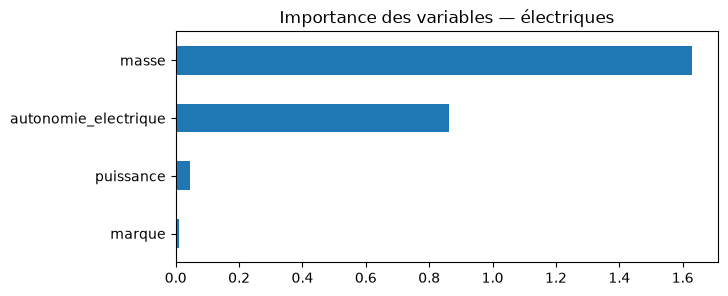


                      masse  puissance  autonomie_electrique  conso_electrique
masse                  1.00       0.66                  0.51              0.66
puissance              0.66       1.00                  0.45              0.39
autonomie_electrique   0.51       0.45                  1.00             -0.18
conso_electrique       0.66       0.39                 -0.18              1.00


In [20]:
r_el = permutation_importance(modele_el, Xe_te, ye_te, n_repeats=15, random_state=42)

imp_el = pd.Series(r_el.importances_mean, index=num_cols_el + cat_cols_el).sort_values()
imp_el.plot(kind="barh", figsize=(7, 3))
plt.title("Importance des variables — électriques")
plt.show()

print()
print(elec[["masse", "puissance", "autonomie_electrique", "conso_electrique"]].corr().round(2))

In [21]:
joblib.dump(modele_el, "models/eu_conso_electrique.pkl")

catalogue.to_csv("data/catalogue_fr_2025.csv", index=False)
print("Modèles et catalogue sauvegardés")
print(os.listdir("models"))

Modèles et catalogue sauvegardés
['eu_conso.pkl', 'eu_conso_electrique.pkl', 'model_electrique.pkl', 'model_hybride.pkl', 'model_thermique.pkl']
